In [48]:
import torch
import torchvision
import torchvision.transforms as transforms

from epiuc.uncertainty.classification import LeNet_MNIST
from epiuc.uncertainty.wrapper import Ensemble_Classifier
from property_procedures.utils import ensemble_probs, total_uncertainty_ensemble, epistemic_uncertainty_ensemble, \
    aleatoric_uncertainty_ensemble

In [49]:
from config import DATALOADER_CONFIGS, BACKEND


def load_mnist(vali_size=0.1, generator=None, loading_configs=DATALOADER_CONFIGS, ROOT_PATH="../data"):
    """
    Load MNIST dataset.
    See `load_image_data` for more details on the arguments.
    :return: MNIST trainloader, valloader, testloader
    """

    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize(mean=[0.1307], std=[0.3081])]
    )

    trainset = torchvision.datasets.MNIST(
        root=ROOT_PATH, train=True, download=True, transform=transform
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, **loading_configs
    )

    testset = torchvision.datasets.MNIST(
        root=ROOT_PATH, train=False, download=True, transform=transform
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=loading_configs["batch_size"],
        shuffle=False,
        num_workers=loading_configs["num_workers"],
        pin_memory=loading_configs["pin_memory"]
    )

    return trainloader, testloader

In [50]:
trainloader, testloader = load_mnist()

In [51]:
lenet_model = LeNet_MNIST(drop_prob=0.5, in_channels=1, image_width=28, image_heigth=28)
ensemble_lenet = Ensemble_Classifier(
    base_model=lenet_model,
    n_models=20,
    random_state=42
)
ensemble_lenet.load("../models/MNIST/Ensemble_Classification/")
ensemble_lenet.compile(backend=BACKEND)
ensemble_lenet.to(device=torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"))

Ensemble_Classifier()

# Train Ensemble of LeNet models

In [52]:
iter_test = iter(testloader)
all_test_images, all_test_labels = [], []
for image_batch, label_batch in iter_test:
    all_test_images.append(image_batch)
    all_test_labels.append(label_batch)
all_test_images = torch.cat(all_test_images, dim=0)
all_test_labels = torch.cat(all_test_labels, dim=0)
all_test_images.shape

torch.Size([10000, 1, 28, 28])

In [53]:
for idx, image in enumerate(all_test_images):
    if image.shape != (1, 28, 28):
        raise ValueError("Image shape is not correct. Expected (1, 28, 28), got {}".format(image.shape))
    prob = ensemble_lenet.predict(image.view(1, *image.shape))[0].max()
    if prob < 1:
        print("Image with low probability: ", prob.item())
        print("Image shape: ", image.shape)
        break

Image with low probability:  0.8403400182723999
Image shape:  torch.Size([1, 28, 28])


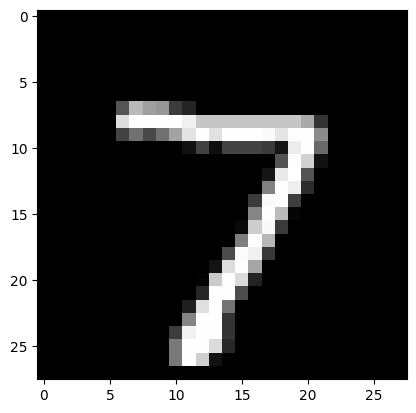

Label =  tensor(7)


In [54]:
# visualize the image
import matplotlib.pyplot as plt
plt.imshow(image.squeeze().numpy(), cmap="gray")
plt.show()
print("Label = ", all_test_labels[idx])

In [55]:
print(ensemble_lenet.predict(image.view(1, *image.shape),raw_output=False)[0])

tensor([[0.0135, 0.0223, 0.0145, 0.0144, 0.0157, 0.0118, 0.0119, 0.8403, 0.0181,
         0.0375]], grad_fn=<CatBackward0>)


In [ ]:
from property_procedures import validity_loss_function, counter_factual_optimization_routine

point_of_interest = image.view(1, *image.shape)  # Reshape to (1, 1, 28, 28) for the model
DESIRED_CLASS = 9
MAX_STEPS = 5000
DELTA = 4
N_POINTS = 100
OPTIMIZER_LR = 0.2
PROB_WEIGHT = 1
LAMBDA_1 = 1
LAMBDA_2 = 1
PATIENCE = 50
DESIRED_VALIDITY = 0.8


counter_factual, counter_factual_steps = counter_factual_optimization_routine(
            point_to_explain=point_of_interest,
            model=ensemble_lenet,
            probability_function=ensemble_probs,
            desired_class=DESIRED_CLASS,
            loss_function=validity_loss_function,
            aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
            MAX_STEPS=MAX_STEPS,
            delta=DELTA,
            n_points=N_POINTS,
            lr=OPTIMIZER_LR,
            DESIRED_VALIDITY=DESIRED_VALIDITY,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            patience=PATIENCE,
            optimization_method="sgd",
        )

Patience limit reached.


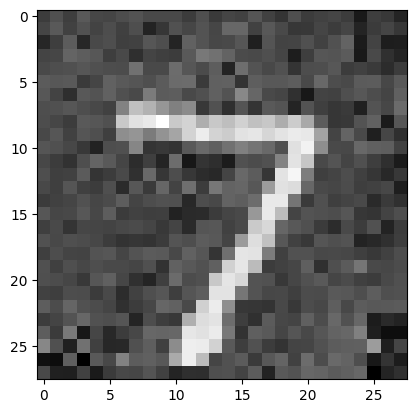

In [57]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


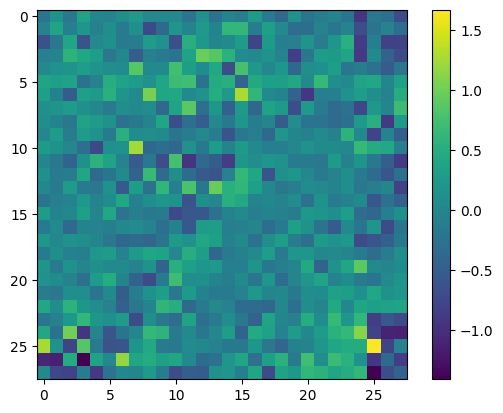

In [58]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [59]:
from property_procedures import discriminative_loss_function, counter_factual_optimization_routine

counter_factual, counter_factual_steps = counter_factual_optimization_routine(
            point_to_explain=point_of_interest,
            model=ensemble_lenet,
            probability_function=ensemble_probs,
            desired_class=DESIRED_CLASS,
            loss_function=discriminative_loss_function,
            aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
            MAX_STEPS=MAX_STEPS,
            delta=DELTA,
            n_points=N_POINTS,
            lr=OPTIMIZER_LR,
            DESIRED_VALIDITY=DESIRED_VALIDITY,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            patience=PATIENCE,
            optimization_method="sgd",
        )

Patience limit reached.


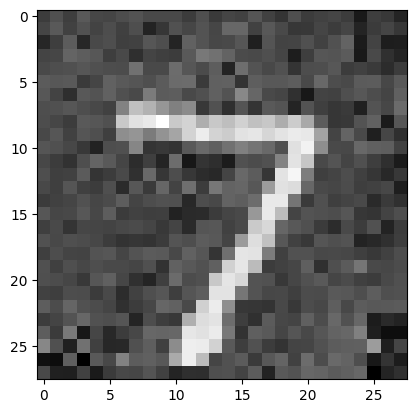

In [60]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


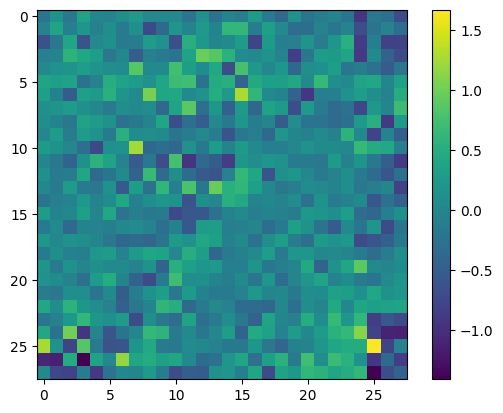

In [61]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [62]:
print(ensemble_lenet.predict(counter_factual, raw_output=False)[0])
print(ensemble_lenet.predict(counter_factual, raw_output=True)[1])

tensor([[0.0000, 0.0500, 0.0500, 0.0000, 0.0500, 0.1500, 0.0000, 0.0000, 0.0000,
         0.7000]], grad_fn=<CatBackward0>)
tensor([[4.2717e-01, 7.2000e-07, 4.2717e-01]], grad_fn=<CatBackward0>)


## Discriminative Loss Function 2

In [ ]:
from property_procedures import feasable_loss_function, counter_factual_optimization_routine

counter_factual, counter_factual_steps = counter_factual_optimization_routine(
            point_to_explain=point_of_interest,
            model=ensemble_lenet,
            probability_function=ensemble_probs,
            desired_class=DESIRED_CLASS,
            loss_function=feasable_loss_function,
            aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
            MAX_STEPS=MAX_STEPS,
            delta=DELTA,
            n_points=N_POINTS,
            lr=OPTIMIZER_LR,
            DESIRED_VALIDITY=DESIRED_VALIDITY,
            p_weight=PROB_WEIGHT,
            lambda_1=LAMBDA_1,
            lambda_2=LAMBDA_2,
            patience=PATIENCE,
            optimization_method="sgd",
        )

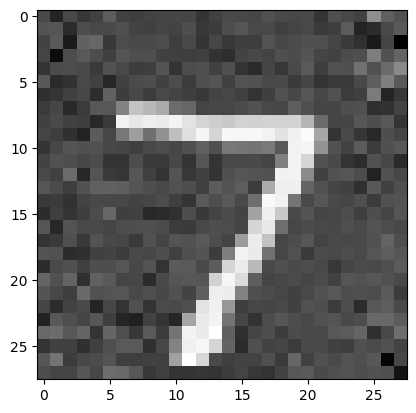

In [64]:
plt.imshow(counter_factual.squeeze().numpy(), cmap="gray")
plt.show()


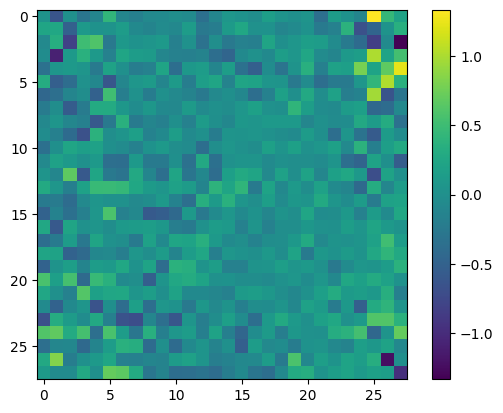

In [65]:
plt.imshow(counter_factual.squeeze().numpy() - image.squeeze().numpy())
plt.colorbar()
plt.show()

In [66]:
print(ensemble_lenet.predict(counter_factual, raw_output=False)[0])
print(ensemble_lenet.predict(counter_factual, raw_output=True)[1])

tensor([[0.0000, 0.0000, 0.0000, 0.1500, 0.0000, 0.2500, 0.0000, 0.5500, 0.0000,
         0.0500]], grad_fn=<CatBackward0>)
tensor([[4.8195e-01, 7.2000e-07, 4.8195e-01]], grad_fn=<CatBackward0>)
